## Task 1 - Implementation and Algorithm Trace

`A = [4, 10, 3, 5, 1, 8, 7, 6]`


In [1]:
def max_heapify(A, heap_size, i):
    while True:
        left = 2 * i + 1
        right = 2 * i + 2
        largest = i

        if left < heap_size and A[left] > A[largest]:
            largest = left
        if right < heap_size and A[right] > A[largest]:
            largest = right

        if largest == i:
            return

        A[i], A[largest] = A[largest], A[i]
        i = largest


def build_max_heap(A):
    for i in range(len(A) // 2 - 1, -1, -1):
        max_heapify(A, len(A), i)


def heap_sort_increasing(A, trace=False):
    A = A.copy()
    if trace:
        print("Original array:")
        print(A)

    build_max_heap(A)
    if trace:
        print("\nMax-heap:")
        print(A)

    for end in range(len(A) - 1, 0, -1):
        A[0], A[end] = A[end], A[0]
        max_heapify(A, end, 0)
        if trace:
            print(f"\nAfter moving maximum to position {end + 1}:")
            print(A)

    if trace:
        print("\nFinal sorted array:")
        print(A)
    return A


A = [4, 10, 3, 5, 1, 8, 7, 6]
heap_sort_increasing(A, trace=True)


Original array:
[4, 10, 3, 5, 1, 8, 7, 6]

Max-heap:
[10, 6, 8, 5, 1, 3, 7, 4]

After moving maximum to position 8:
[8, 6, 7, 5, 1, 3, 4, 10]

After moving maximum to position 7:
[7, 6, 4, 5, 1, 3, 8, 10]

After moving maximum to position 6:
[6, 5, 4, 3, 1, 7, 8, 10]

After moving maximum to position 5:
[5, 3, 4, 1, 6, 7, 8, 10]

After moving maximum to position 4:
[4, 3, 1, 5, 6, 7, 8, 10]

After moving maximum to position 3:
[3, 1, 4, 5, 6, 7, 8, 10]

After moving maximum to position 2:
[1, 3, 4, 5, 6, 7, 8, 10]

Final sorted array:
[1, 3, 4, 5, 6, 7, 8, 10]


### Heap Representation


| Node | Left child | Right child |
|---:|---:|---:|
| 10 | 6 | 8 |
| 6 | 5 | 1 |
| 8 | 3 | 7 |
| 5 | 4 | - |
| 1 | - | - |
| 3 | - | - |
| 7 | - | - |
| 4 | - | - |

1. Every parent is greater than or equal to its children.
2. The largest element is at the root.
3. `MAX-HEAPIFY` restores the max-heap property.
4. The heap size is reduced because the extracted element is already in its final position.


## Task 2 - Modified Heap Sort

`A = [12, 5, 8, 1, 19, 4, 15, 7]`

Expected result: `[19, 15, 12, 8, 7, 5, 4, 1]`


In [1]:
def min_heapify(A, heap_size, i):
    while True:
        left = 2 * i + 1
        right = 2 * i + 2
        smallest = i

        if left < heap_size and A[left] < A[smallest]:
            smallest = left
        if right < heap_size and A[right] < A[smallest]:
            smallest = right

        if smallest == i:
            return

        A[i], A[smallest] = A[smallest], A[i]
        i = smallest


def build_min_heap(A):
    for i in range(len(A) // 2 - 1, -1, -1):
        min_heapify(A, len(A), i)


def heap_sort_decreasing(A, trace=False):
    A = A.copy()
    if trace:
        print("Original array:")
        print(A)

    build_min_heap(A)
    if trace:
        print("\nMin-heap:")
        print(A)

    for end in range(len(A) - 1, 0, -1):
        A[0], A[end] = A[end], A[0]
        min_heapify(A, end, 0)
        if trace:
            print(f"\nAfter moving minimum to position {end + 1}:")
            print(A)

    if trace:
        print("\nFinal sorted array:")
        print(A)
    return A


A = [12, 5, 8, 1, 19, 4, 15, 7]
heap_sort_decreasing(A, trace=True)


Original array:
[12, 5, 8, 1, 19, 4, 15, 7]

Min-heap:
[1, 5, 4, 7, 19, 8, 15, 12]

After moving minimum to position 8:
[4, 5, 8, 7, 19, 12, 15, 1]

After moving minimum to position 7:
[5, 7, 8, 15, 19, 12, 4, 1]

After moving minimum to position 6:
[7, 12, 8, 15, 19, 5, 4, 1]

After moving minimum to position 5:
[8, 12, 19, 15, 7, 5, 4, 1]

After moving minimum to position 4:
[12, 15, 19, 8, 7, 5, 4, 1]

After moving minimum to position 3:
[15, 19, 12, 8, 7, 5, 4, 1]

After moving minimum to position 2:
[19, 15, 12, 8, 7, 5, 4, 1]

Final sorted array:
[19, 15, 12, 8, 7, 5, 4, 1]


A max-heap has a parent greater than or equal to its children. A min-heap has a parent less than or equal to its children.

A min-heap places the minimum element at the end after every extraction, so the result is in decreasing order.


## Task 3 - Counting Comparisons


In [1]:
def heap_sort_with_comparisons(values):
    A = values.copy()
    build_comparisons = 0
    sorting_comparisons = 0

    def heapify(heap_size, i, stage):
        nonlocal build_comparisons, sorting_comparisons
        while True:
            left = 2 * i + 1
            right = 2 * i + 2
            largest = i

            if left < heap_size:
                if stage == "build":
                    build_comparisons += 1
                else:
                    sorting_comparisons += 1
                if A[left] > A[largest]:
                    largest = left

            if right < heap_size:
                if stage == "build":
                    build_comparisons += 1
                else:
                    sorting_comparisons += 1
                if A[right] > A[largest]:
                    largest = right

            if largest == i:
                return
            A[i], A[largest] = A[largest], A[i]
            i = largest

    for i in range(len(A) // 2 - 1, -1, -1):
        heapify(len(A), i, "build")

    for end in range(len(A) - 1, 0, -1):
        A[0], A[end] = A[end], A[0]
        heapify(end, 0, "sort")

    return A, build_comparisons, sorting_comparisons


test_arrays = {
    "Sorted array": [1, 2, 3, 4, 5, 6, 7, 8],
    "Reverse-sorted array": [8, 7, 6, 5, 4, 3, 2, 1],
    "Random array": [7, 2, 8, 4, 1, 6, 5, 3],
}

print(f"{'Input':<23}{'Build heap':>12}{'Sorting stage':>16}{'Total':>8}")
print("-" * 59)
comparison_results = {}
for name, values in test_arrays.items():
    sorted_values, build_count, sort_count = heap_sort_with_comparisons(values)
    total = build_count + sort_count
    comparison_results[name] = (build_count, sort_count, total)
    print(f"{name:<23}{build_count:>12}{sort_count:>16}{total:>8}")
    assert sorted_values == sorted(values)


Input                    Build heap   Sorting stage   Total
-----------------------------------------------------------
Sorted array                     10              17      27
Reverse-sorted array              7              17      24
Random array                     10              15      25


1. The sorted array required the largest number of comparisons.
2. No, the three inputs produced different numbers of comparisons.
3. The initial order changes the number of comparisons, but Heap Sort remains `O(n log n)`.
4. Insertion Sort depends more strongly on the initial order: sorted input is faster and reverse-sorted input is slower.


## Task 4 - Experimental Analysis and Comparison

Each test is repeated 5 times.


Input size n    Average execution time (s)
--------------------------------------------
         100                      0.000131
         500                      0.000885
        1000                      0.002040
        5000                      0.013199
       10000                      0.029445
       50000                      0.214053


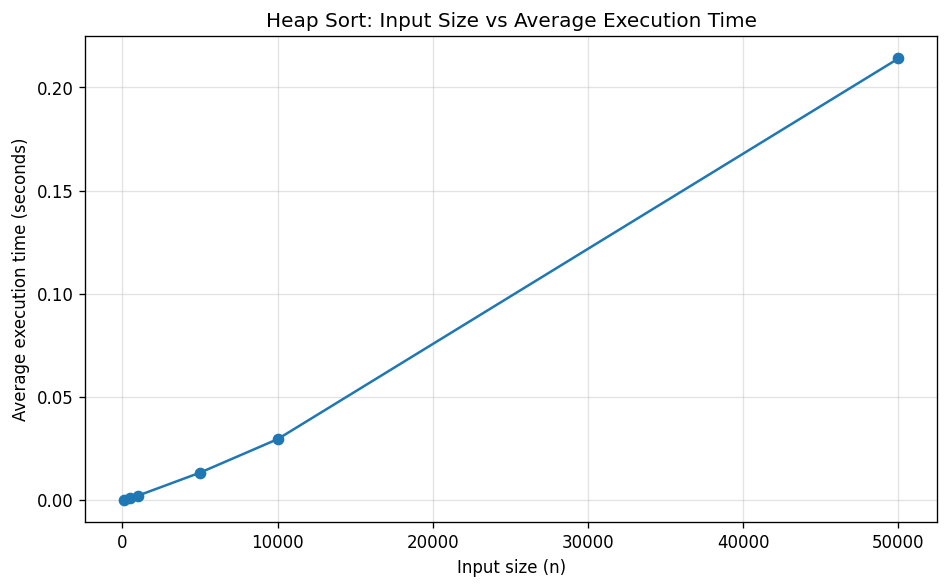

In [1]:
import random
import time


def insertion_sort(A):
    A = A.copy()
    for j in range(1, len(A)):
        key = A[j]
        i = j - 1
        while i >= 0 and A[i] > key:
            A[i + 1] = A[i]
            i -= 1
        A[i + 1] = key
    return A


def merge_sort(A):
    if len(A) <= 1:
        return A
    middle = len(A) // 2
    left = merge_sort(A[:middle])
    right = merge_sort(A[middle:])
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    return merged + left[i:] + right[j:]


def average_time(sort_function, n, trials=5, seed_offset=0):
    times = []
    for trial in range(trials):
        rng = random.Random(20260922 + seed_offset + n * 10 + trial)
        values = [rng.randint(1, 1_000_000) for _ in range(n)]
        start = time.perf_counter()
        result = sort_function(values)
        times.append(time.perf_counter() - start)
        assert result == sorted(values)
    return sum(times) / trials


sizes = [100, 500, 1000, 5000, 10000, 50000]
heap_times = [average_time(heap_sort_increasing, n) for n in sizes]

print(f"{'Input size n':>12}  {'Average execution time (s)':>28}")
print("-" * 44)
for n, elapsed in zip(sizes, heap_times):
    print(f"{n:>12}  {elapsed:>28.6f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, heap_times, marker="o", color="#1f77b4")
plt.xlabel("Input size (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Heap Sort: Input Size vs Average Execution Time")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


      n    Insertion Sort (s)     Merge Sort (s)     Heap Sort (s)
----------------------------------------------------------------------
    100              0.000209           0.000186          0.000161
    500              0.005580           0.000844          0.001094
   1000              0.022061           0.001794          0.002063
   5000              0.584157           0.011113          0.013536
  10000              2.241279           0.022663          0.028005


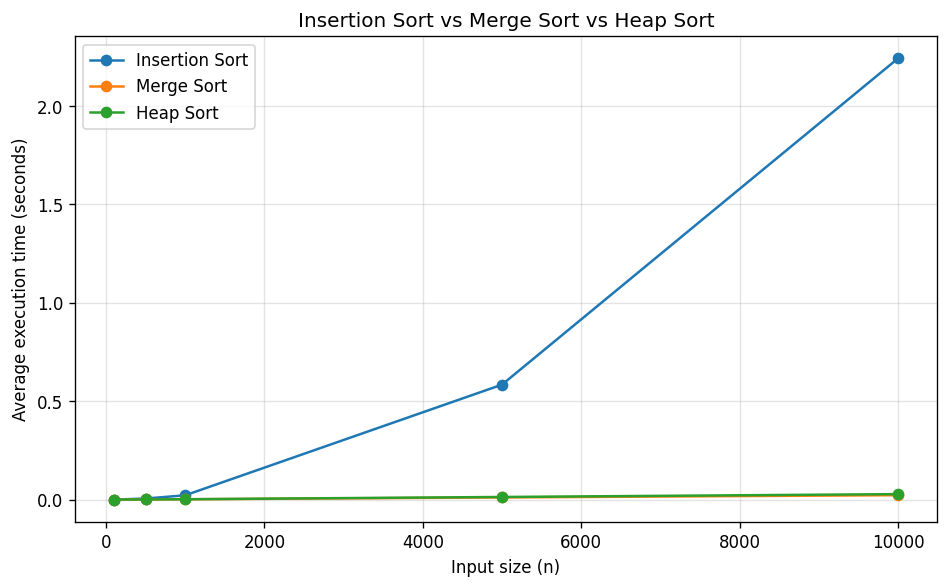

In [1]:
comparison_sizes = [100, 500, 1000, 5000, 10000]
insertion_times = []
merge_times = []
heap_comparison_times = []

for n in comparison_sizes:
    trial_times = {"Insertion Sort": [], "Merge Sort": [], "Heap Sort": []}
    for trial in range(5):
        rng = random.Random(20260922 + n * 100 + trial)
        original = [rng.randint(1, 1_000_000) for _ in range(n)]
        for name, sort_function in [
            ("Insertion Sort", insertion_sort),
            ("Merge Sort", merge_sort),
            ("Heap Sort", heap_sort_increasing),
        ]:
            start = time.perf_counter()
            result = sort_function(original.copy())
            trial_times[name].append(time.perf_counter() - start)
            assert result == sorted(original)

    insertion_times.append(sum(trial_times["Insertion Sort"]) / 5)
    merge_times.append(sum(trial_times["Merge Sort"]) / 5)
    heap_comparison_times.append(sum(trial_times["Heap Sort"]) / 5)

print(f"{'n':>7}  {'Insertion Sort (s)':>20}  {'Merge Sort (s)':>17}  {'Heap Sort (s)':>16}")
print("-" * 70)
for row in zip(comparison_sizes, insertion_times, merge_times, heap_comparison_times):
    print(f"{row[0]:>7}  {row[1]:>20.6f}  {row[2]:>17.6f}  {row[3]:>16.6f}")

plt.figure(figsize=(8, 5))
plt.plot(comparison_sizes, insertion_times, marker="o", label="Insertion Sort")
plt.plot(comparison_sizes, merge_times, marker="o", label="Merge Sort")
plt.plot(comparison_sizes, heap_comparison_times, marker="o", label="Heap Sort")
plt.xlabel("Input size (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Insertion Sort vs Merge Sort vs Heap Sort")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


### Answers

1. The execution time increases as `n` increases.
2. Heap Sort is faster than Insertion Sort for large arrays.
3. Heap Sort and Merge Sort have similar `O(n log n)` growth.
4. The difference from Insertion Sort becomes more noticeable for large arrays.
5. Yes. The results agree with the theoretical running times.


## Theoretical Analysis

1. The height of a binary heap is `floor(log2 n)`.
2. `MAX-HEAPIFY`: `O(log n)`.
3. `BUILD-MAX-HEAP`: `O(n)`.
4. Heap Sort: `O(n log n)`.

| Algorithm | Best Case | Average Case | Worst Case |
|---|---:|---:|---:|
| Insertion Sort | `O(n)` | `O(n²)` | `O(n²)` |
| Merge Sort | `O(n log n)` | `O(n log n)` | `O(n log n)` |
| Heap Sort | `O(n log n)` | `O(n log n)` | `O(n log n)` |

Building the heap costs `O(n)`. There are `n - 1` extractions. After each extraction, `MAX-HEAPIFY` takes `O(log n)`. Therefore, Heap Sort takes `O(n log n)`.


## Conclusion

Heap Sort uses a binary heap to sort an array. The experiments show that Heap Sort scales better than Insertion Sort for large arrays and has `O(n log n)` running time.
